In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

In [2]:
class AgentState(TypedDict, total=False):
  name: str
  values: List[int]
  result: str


In [3]:
def ask_name(state: AgentState) -> AgentState:
  """
  Prompts the user for thier name and updates the shared state
  """
  print("Welcome to the Budget Analyzer")
  print("What's your name?")
  state["name"] = input(">>")
  return state

In [4]:
def ask_values(state: AgentState) -> AgentState:
  """
  Prompts the user to enter a list of recent purchase amounts and updates state
  """
  print(f'Hi {state['name']}! Enter the last 5 financial transactions (seperated by commas): ')
  raw = input(">>")
  try:
    values = [int(v.strip()) for v in
              raw.split(',') if v.strip()]
    print(f'Values: {values}')
    if len(values) < 1:
        raise ValueError()
  except ValueError:
    print("Please enter only valid numbers separated by commas.")
    return ask_values(state)
  state['values'] = values
  return state


In [5]:
import inspect
print(inspect.getsource(ask_values))

def ask_values(state: AgentState) -> AgentState:
  """
  Prompts the user to enter a list of recent purchase amounts and updates state
  """
  print(f'Hi {state['name']}! Enter the last 5 financial transactions (seperated by commas): ')
  raw = input(">>")
  try:
    values = [int(v.strip()) for v in
              raw.split(',') if v.strip()]
    print(f'Values: {values}')
    if len(values) < 1:
        raise ValueError()
  except ValueError:
    print("Please enter only valid numbers separated by commas.")
    return ask_values(state)
  state['values'] = values
  return state



In [6]:
def analyze_and_report(state: AgentState) -> AgentState:
  """
  Calculates total spending, classifies the user as a Saver or a Spender, stores the results, and prints a summary message
  """
  print("State Recieved: ", state)
  total = sum(state['values'] )
  result = "Saver" if total > 0 else "Spender"
  state["result"] = result

  print("\n?? Budget Summary")
  print(f'Name: {state['name']}')
  print(f'Total Spent: ${total}')
  print(f'Result: You are a {state['result']}!')
  return state

In [7]:
import inspect
print("=== ask_values currently loaded ===")
print(inspect.getsource(ask_values))

print("\n=== TypedDict total flag ===")
print("AgentState.__total__ =", AgentState.__total__)

=== ask_values currently loaded ===
def ask_values(state: AgentState) -> AgentState:
  """
  Prompts the user to enter a list of recent purchase amounts and updates state
  """
  print(f'Hi {state['name']}! Enter the last 5 financial transactions (seperated by commas): ')
  raw = input(">>")
  try:
    values = [int(v.strip()) for v in
              raw.split(',') if v.strip()]
    print(f'Values: {values}')
    if len(values) < 1:
        raise ValueError()
  except ValueError:
    print("Please enter only valid numbers separated by commas.")
    return ask_values(state)
  state['values'] = values
  return state


=== TypedDict total flag ===
AgentState.__total__ = False


In [8]:
graph = StateGraph(AgentState)
graph.add_node("ask_name", ask_name)
graph.add_node("ask_values", ask_values)
graph.add_node('analyze_and_report', analyze_and_report)


In [9]:
graph.set_entry_point('ask_name')
graph.add_edge('ask_name', 'ask_values')
graph.add_edge('ask_values', 'analyze_and_report')
graph.add_edge('analyze_and_report', END)

In [10]:
compiled_graph = graph.compile()

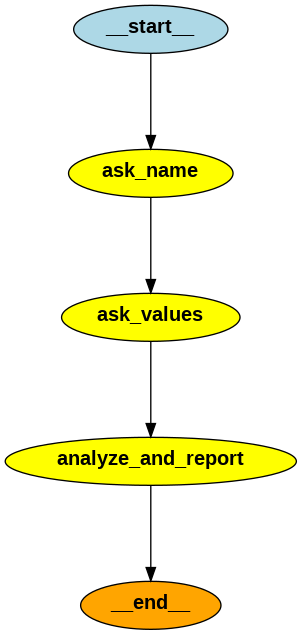

In [11]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(compiled_graph.get_graph().draw_png()))

In [ ]:
compiled_graph.invoke({})

Welcome to the Budget Analyzer
What's your name?


In [ ]:
# from IPython.display import Image, display

# png_bytes = compiled_graph.get_graph().draw_mermaid_png()
# display(Image(png_bytes))